<a href="https://colab.research.google.com/github/kimjiji8105/class2025Spring/blob/main/Toxic_Comment_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 악성 댓글 탐지 모델 성능 비교 보고서

## 1. 개요  
온라인 서비스에서 악성 댓글이 지속적으로 노출될 경우 이용자의 경험이 크게 저하될 수 있습니다. 기존 TF-IDF 기반 분류 모델은 단어 빈도 중심으로 작동하기 때문에 문맥을 충분히 반영하기 어려우며 반어적 표현이나 간접적인 혐오 표현에 대한 탐지에도 한계가 있습니다. 이에 본 프로젝트에서는 Baseline 모델(TF-IDF + Logistic Regression)과 KoBERT 기반 파인튜닝 모델을 동일한 이진 분류 과제에 적용하여 성능을 비교하고 실제 서비스 환경에서의 적용 가능성을 검토하였습니다.

## 2. 데이터 구성 및 전처리  
- 사용한 데이터셋은 korean_unsmile_dataset(18,742건)과 hatescore-korean-hate-speech(11,108건)으로 총 29,850건의 문장을 확보하였습니다.  
- 두 데이터셋의 9개 혐오 표현 카테고리를 문제성(1)과 정상(0)으로 이진 라벨링하여 통합하였습니다.  
- Clean=1로 표시된 항목은 정상(0)으로, 혐오 또는 악플=0으로 되어 있던 항목은 문제성(1)으로 재정의하여 라벨을 통일하였습니다.  
- 전체 데이터는 stratified 방식으로 학습, 검증, 테스트 데이터셋을 8:1:1 비율로 분할하였습니다.

## 3. 모델 구성 및 학습 방법

### Baseline  
- 텍스트는 TF-IDF 방식으로 벡터화하였으며 n-gram 범위는 1~2, max_features는 40,000, 최소 등장 빈도는 2로 설정하였습니다.  
- 분류기는 LogisticRegressionCV를 사용하였고 5-Fold 교차검증을 적용하였으며 클래스 불균형을 보정하기 위해 class_weight를 'balanced'로 지정하였습니다.

### KoBERT Fine-tuning  
- 사전학습 모델로 monologg/kobert를 사용하고 분류 헤드(num_labels=2)를 추가하였으며 LoRA(r=8, α=16)를 적용하여 부분 파인튜닝을 수행하였습니다.  
- 학습 설정은 epochs=3, batch_size=16, learning_rate=1e-4이며 FP16을 활용하여 학습 효율을 높였습니다.  
- 검증 기준은 F1-score로 설정하여 가장 성능이 우수한 모델을 저장하였습니다.

### 평가 지표  
- 주요 평가지표는 문제성(1) 클래스의 Precision, Recall, F1-score이며 전체 Accuracy도 함께 고려하였습니다.

## 4. 성능 비교 결과  

| 모델 | Precision(정상) | Recall(정상) | F1-score(정상) | Precision(문제성) | Recall(문제성) | F1-score(문제성) | Accuracy |
|------|------------------:|---------------:|-----------------:|-------------------:|----------------:|------------------:|----------:|
| Baseline | 0.9464 | 0.6660 | 0.7818 | 0.7443 | 0.9627 | 0.8395 | 0.8151 |
| KoBERT   | 0.8611 | 0.8640 | 0.8625 | 0.8649 | 0.8620 | 0.8634 | 0.8630 |

KoBERT 모델은 Precision과 Recall이 균형 있게 나타났으며 전체 정확도는 86.30%로 Baseline 모델보다 4.79%포인트 높은 수치를 기록하였습니다. Baseline 모델은 문제성 문장에 대한 탐지율(Recall)은 높았으나 정상 문장을 문제성으로 잘못 분류하는 오탐률(False Positive)이 상대적으로 높게 나타났습니다. KoBERT는 오탐을 절반 이하로 줄이며 전반적으로 안정적인 분류 성능을 보였습니다. 또한 문맥 기반 판단이 가능하기 때문에 반어적 표현이나 간접적인 혐오 표현에 대해서도 비교적 효과적인 탐지를 수행할 수 있었습니다.

## 5. 인사이트 분석  

- Baseline 모델은 문제성 문장을 놓치는 경우(FN)는 적었으나 정상 문장을 문제성으로 오분류하는 비율(FP)이 높았습니다. (정상→문제성: 496건, 문제성→정상: 56건)  
- KoBERT는 오탐을 크게 줄인 반면 누락(FN)은 소폭 증가하였으며 FP와 FN이 균형 있게 분포되어 전체적인 분류 안정성이 개선되었습니다. (FP: 202건, FN: 207건)  
- KoBERT는 혐오 표현의 다양한 유형에 대해 고른 탐지 성능을 보였으며 문맥이 복잡하거나 간접적인 표현에서도 상대적으로 강한 특성을 나타냈습니다.  
- 데이터셋에 반복적이고 명시적인 혐오 표현이 많았기 때문에 TF-IDF 기반 모델도 일정 수준의 성능을 확보할 수 있었던 것으로 판단됩니다.  
- 실제 서비스에서는 오탐 최소화가 중요하므로 KoBERT의 판단 일관성과 안정성은 실용적인 강점으로 평가됩니다.

## 6. 한계점 및 향후 방향  

- 데이터셋이 공개된 이슈 중심으로 구성되어 있어 정치나 연예 등 특정 분야에 편향될 가능성이 존재합니다.  
- KoBERT는 모델 구조상 추론 속도가 느려 실시간 서비스 적용에 있어 최적화가 요구됩니다.  
- LoRA 파라미터, 학습률 등 하이퍼파라미터의 추가 조정과 함께 모델 경량화를 통한 효율 개선이 필요합니다.

## 7. 결론  

- KoBERT 파인튜닝 모델은 Baseline 모델에 비해 오탐률을 낮추고 정확도를 높이며 문제성 여부에 대한 분류 성능 전반에서 균형 있는 결과를 보였습니다.  
- 수치상 개선 폭은 제한적이었으나 이는 이진 분류라는 문제 정의와 데이터 구성의 단순성에 기인한 것으로 해석됩니다.  
- 문맥 이해와 판단 일관성이 중요한 실제 서비스 환경에서는 KoBERT 기반 모델이 더욱 적합한 선택지로 판단됩니다.


#<h2>1. 환경 세팅</h2>

In [1]:
# #처음 실행 후 세션 다시 시작 - plt 한글 깨짐 현상 방지
# !sudo apt-get install -y fonts-nanum       # Nanum 폰트 설치
# !sudo fc-cache -fv                         # 폰트 캐시 갱신
# !rm -rf ~/.cache/matplotlib                 # matplotlib 캐시 삭제

In [2]:
!pip install -q transformers evaluate accelerate datasets koco peft==0.13.2

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
from datasets import load_dataset, Dataset, DatasetDict
import koco
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from google.colab import drive
from transformers.integrations import WandbCallback


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import evaluate

import joblib
import torch

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import make_pipeline
from peft import LoraConfig, get_peft_model
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

In [4]:
#행·열 제한 해제
#pd.set_option('display.max_rows',    None)   # 행 모두
pd.set_option('display.max_columns', None)   # 열 모두

#한글 깨짐 해결
plt.rc('font', family='NanumBarunGothic')       # 설치된 나눔바른고딕 계열
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 깨짐 방지

In [5]:
#Drive 마운트
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
#dir path 지정
output_dir = '/content/drive/MyDrive/Toxic_Comment_Detection/kobert_binary_outputs/'
model_dir = '/content/drive/MyDrive/Toxic_Comment_Detection/models/'

In [7]:
#변수 정의
cols = ['category', '문장', '여성/가족', '남성', '성소수자', '인종/국적', '연령', '지역', '종교', '기타 혐오', '악플/욕설', 'target']
sub_cols = ['여성/가족', '남성', '성소수자', '인종/국적', '연령', '지역', '종교', '기타 혐오', '악플/욕설']

In [8]:
#output 저장 폴더 생성
folders = [output_dir, model_dir]

for path in folders:
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")

Created: /content/drive/MyDrive/Toxic_Comment_Detection/kobert_binary_outputs/
Created: /content/drive/MyDrive/Toxic_Comment_Detection/models/


# <h2> 2. 데이터 로드 및 확인 </h2>

- 사용 데이터
    - korean_unsmile_dataset : https://github.com/smilegate-ai/korean_unsmile_dataset.git
    - hatescore-korean-hate-speech: https://github.com/sgunderscore/hatescore-korean-hate-speech.git

- 확인 내용
    - 데이터 오류 여부
    - 정상, 부정 여부

## 2.1 unsmile_df

- 해당 과제에서 문제성 여부로 이진 라벨을 구성할 것이므로 문제성 글은 1, 정상은 0으로 매핑됩니다.
- 이에 따라 unsmile_df의 기존 라벨에서 Clean=1이었던 항목은 0으로 혐오·악플=0이었던 항목은 1로 재정의해야 합니다.

**[테이블 로드]**

In [9]:
datasets = load_dataset('smilegate-ai/kor_unsmile')
print(datasets)

unsmile_df = pd.concat([pd.DataFrame(datasets['train']), pd.DataFrame(datasets['valid'])])

dataset_infos.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

valid-00000-of-00001.parquet:   0%|          | 0.00/290k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15005 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/3737 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['문장', '여성/가족', '남성', '성소수자', '인종/국적', '연령', '지역', '종교', '기타 혐오', '악플/욕설', 'clean', '개인지칭', 'labels'],
        num_rows: 15005
    })
    valid: Dataset({
        features: ['문장', '여성/가족', '남성', '성소수자', '인종/국적', '연령', '지역', '종교', '기타 혐오', '악플/욕설', 'clean', '개인지칭', 'labels'],
        num_rows: 3737
    })
})


**[구조 확인]**

In [10]:
unsmile_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18742 entries, 0 to 3736
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   문장      18742 non-null  object
 1   여성/가족   18742 non-null  int64 
 2   남성      18742 non-null  int64 
 3   성소수자    18742 non-null  int64 
 4   인종/국적   18742 non-null  int64 
 5   연령      18742 non-null  int64 
 6   지역      18742 non-null  int64 
 7   종교      18742 non-null  int64 
 8   기타 혐오   18742 non-null  int64 
 9   악플/욕설   18742 non-null  int64 
 10  clean   18742 non-null  int64 
 11  개인지칭    18742 non-null  int64 
 12  labels  18742 non-null  object
dtypes: int64(11), object(2)
memory usage: 2.0+ MB


In [11]:
#중복 있음 확인
unsmile_df.describe(include='all')

,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,clean,개인지칭,labels
count,18742,18742.000000,18742.000000,18742.000000,18742.000000,18742.000000,18742.000000,18742.000000,18742.000000,18742.000000,18742.000000,18742.000000,18742
unique,18741,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81
top,이시국에 먼말이더냐,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
freq,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4674
mean,NaN,0.106339,0.089692,0.075819,0.114929,0.039964,0.070003,0.078487,0.037509,0.209636,0.249386,0.020756,NaN
std,NaN,0.308279,0.285747,0.264715,0.318945,0.195879,0.255159,0.268943,0.190011,0.407060,0.432669,0.142569,NaN
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN


In [12]:
unsmile_df.isnull().sum()

,0
문장,0
여성/가족,0
남성,0
성소수자,0
인종/국적,0
연령,0
지역,0
종교,0
기타 혐오,0
악플/욕설,0


In [13]:
unsmile_df.head()

,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,clean,개인지칭,labels
0,일안하는 시간은 쉬고싶어서 그런게 아닐까,0,0,0,0,0,0,0,0,0,1,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
1,아동성범죄와 페도버는 기록바 끊어져 영원히 고통 받는다. 무슬림 50퍼 근친이다. ...,0,0,0,0,0,0,1,0,0,0,0,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]"
2,루나 솔로앨범 나왔을 때부터 머모 기운 있었음 ㅇㅇ Keep o doin 진짜 띵...,0,0,0,0,0,0,0,0,0,1,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
3,홍팍에도 어버이연합인가 보내요 뭐 이런뎃글 있는데 이거 어버이연합측에 신고하면 그쪽...,0,0,0,0,0,0,0,0,0,1,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
4,아놔 왜 여기 댓들은 다 여자들이 김치녀라고 먼저 불렸다! 여자들은 더 심하게 그런...,1,0,0,0,0,0,0,0,0,0,0,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


In [14]:
unsmile_df['clean'].value_counts()

,count
clean,
0,14068
1,4674


In [15]:
unsmile_df.loc[:,'여성/가족':'clean'].value_counts().reset_index()

#clean이 1이면서 혐오표현이 1인 경우(오류)는 없지만, 혐오 표현이 2개 이상인 경우는 존재
#우리는 clean 여부만 사용할 것이므로 문제 X

,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,clean,count
0,0,0,0,0,0,0,0,0,0,1,4674
1,0,0,0,0,0,0,0,0,1,0,3929
2,1,0,0,0,0,0,0,0,0,0,1614
3,0,0,0,1,0,0,0,0,0,0,1574
4,0,1,0,0,0,0,0,0,0,0,1409
...,...,...,...,...,...,...,...,...,...,...,...
76,1,0,1,0,1,0,0,0,0,0,1
77,1,0,1,1,1,1,0,1,0,0,1
78,1,0,1,1,1,0,0,0,0,0,1
79,1,0,1,1,0,1,1,0,0,0,1


In [16]:
unsmile_df['labels']

,labels
0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
1,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]"
2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
4,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
...,...
3732,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
3733,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]"
3734,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]"
3735,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


In [17]:
# 중복 제거 - 개인적으론.. 악풀까진 아닌듯.. clean 1로 남기기
unsmile_df[unsmile_df.duplicated('문장', keep=False)]

,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,clean,개인지칭,labels
6492,이시국에 먼말이더냐,0,0,0,0,0,0,0,0,1,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]"
6549,이시국에 먼말이더냐,0,0,0,0,0,0,0,0,0,1,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"


In [18]:
unsmile_df.drop_duplicates('문장', keep='last', inplace=True)

## 2.2 hatescore_df

**[테이블 로드]**

In [19]:
# “main” 브랜치의 HateScore.csv 파일에 접근
url = (
    "https://raw.githubusercontent.com/"
    "sgunderscore/hatescore-korean-hate-speech/"
    "main/"                       # ← 여기에 브랜치 이름이 꼭 들어가야 합니다
    "HateScore.csv"
)

In [20]:
# CSV 파일이기 때문에 sep은 기본 쉼표(,)를 사용
hatescore_df  = pd.read_csv(url, index_col=0)
hatescore_df

,comment,macrolabel,microlabel,source
0,절라남도 벌레?,혐오발언,지역,온라인 댓글
1,부산에서 학식먹었는데 mt 동기mt 동아리mt 단한번도 해운대 안감 부산 현지인들이...,혐오발언,지역,온라인 댓글
2,쌍도 여혐끝판왕의성지,혐오발언,지역,온라인 댓글
3,제목보고 전라도 직감,혐오발언,지역,온라인 댓글
4,홍어지 병신아 ㅋㅋㅋ,혐오발언,지역,온라인 댓글
...,...,...,...,...
11103,안녕하세요 이란에서 태어난 사람인가?,Clean,NaN,규칙 기반 생성
11104,트랜스젠더인 거 같네,Clean,NaN,규칙 기반 생성
11105,저 분은 리비아 친구 처음 만나네,Clean,NaN,규칙 기반 생성
11106,쟤는 독일 사람 처음 만나네,Clean,NaN,규칙 기반 생성


**[구조 확인]**

In [21]:
hatescore_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11108 entries, 0 to 11107
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   comment     11108 non-null  object
 1   macrolabel  11108 non-null  object
 2   microlabel  934 non-null    object
 3   source      11108 non-null  object
dtypes: object(4)
memory usage: 433.9+ KB


In [22]:
hatescore_df.describe(include='all')

,comment,macrolabel,microlabel,source
count,11108,11108,934,11108
unique,11108,3,43,3
top,그는 독일에서 온 사람 처음 만나네,Clean,지역,규칙 기반 생성
freq,1,10174,333,7115


In [23]:
hatescore_df.isnull().sum()

,0
comment,0
macrolabel,0
microlabel,10174
source,0


In [24]:
hatescore_df['macrolabel'].value_counts()

,count
macrolabel,
Clean,10174
혐오발언,782
단순 악플,152


In [25]:
hatescore_df.head()

,comment,macrolabel,microlabel,source
0,절라남도 벌레?,혐오발언,지역,온라인 댓글
1,부산에서 학식먹었는데 mt 동기mt 동아리mt 단한번도 해운대 안감 부산 현지인들이...,혐오발언,지역,온라인 댓글
2,쌍도 여혐끝판왕의성지,혐오발언,지역,온라인 댓글
3,제목보고 전라도 직감,혐오발언,지역,온라인 댓글
4,홍어지 병신아 ㅋㅋㅋ,혐오발언,지역,온라인 댓글


In [26]:
hatescore_df['microlabel'].value_counts()

,count
microlabel,
지역,333
단순 악플,152
성소수자,112
여성/가족,72
연령,40
종교,34
기타 혐오,33
인종/국적,25
"종교, 지역",14


In [27]:
# hatescore_df 내 단순 악플은 unsmile_df 내 악플/욕설로 대체해도 될듯
hatescore_df.loc[:,'macrolabel':'microlabel'].value_counts().reset_index()

,macrolabel,microlabel,count
0,혐오발언,지역,333
1,단순 악플,단순 악플,152
2,혐오발언,성소수자,112
3,혐오발언,여성/가족,72
4,혐오발언,연령,40
5,혐오발언,종교,34
6,혐오발언,기타 혐오,33
7,혐오발언,인종/국적,25
8,혐오발언,"종교, 지역",14
9,혐오발언,남성,14


In [28]:
hatescore_df[hatescore_df['macrolabel'] == '단순 악플']

,comment,macrolabel,microlabel,source
700,진짜 존나위선임 시발ㅋㅋ 자기집팔아서 시골에 땅사고 지상낙원만들어줄것도아니고 좆도남...,단순 악플,단순 악플,온라인 댓글
701,띵문이다이기야 조팔 숙명대학교에서 코르셋전시막자는 말도 못하는정도면 좆국사회는 얼마...,단순 악플,단순 악플,온라인 댓글
702,아니 씨발 겨우 키나 외모 갖고 팩트지적한걸로 멘탈 나가서 할말까지 까먹노 씨발 을...,단순 악플,단순 악플,온라인 댓글
703,운마새끼 왜 이래?왜 내 포인트와 잉여력이 얌생이 몰듯이 자꾸 야금야금 내려 가냐?...,단순 악플,단순 악플,온라인 댓글
704,배경봐라 후팔 기안민국 아니노 ㅋㅋ,단순 악플,단순 악플,온라인 댓글
...,...,...,...,...
847,머하는빡머갈이며 손님으로 파퀴를... pc빙알바로 예상해봄,단순 악플,단순 악플,온라인 댓글
848,니들은 일단 열대쯤 맞고 이야기 다시해보자.,단순 악플,단순 악플,온라인 댓글
849,공무원 임금픽크제 도입하고 무능한 밥벌레들 구조조정해서 나누어 가져라 사기업 계약직...,단순 악플,단순 악플,온라인 댓글
850,솔직히 잘뒤짐ㅎ,단순 악플,단순 악플,온라인 댓글


In [29]:
unsmile_df[unsmile_df['악플/욕설'] == 1]

,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,clean,개인지칭,labels
7,나이쳐먹고 피시방가는 놈들은 대가리에 똥만찬 놈들임,0,0,0,0,0,0,0,0,1,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]"
17,위로와 격려를 호텔에서 해? 왜? 저여자도 정상은 아니구만 완전 지네 할아버지보다 ...,0,0,0,0,0,0,0,0,1,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]"
19,띄울사람이 진짜 없긴 없나보다,0,0,0,0,0,0,0,0,1,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]"
22,쑈 빼고 아무것도 없는 개돼지 정권이노 탄핵 개힘조,0,0,0,0,0,0,0,0,1,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]"
27,뭐하냐 기업이네 기업이여 기업에 돈갖다 받치는 어이없는 시키들도 문제다,0,0,0,0,0,0,0,0,1,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3721,와줘서 고맙다 이기. 보지답지 못하게 처음엔 쫄았는데 웜상들 만나서 놈딱 기뻐서 목...,0,0,0,0,0,0,0,0,1,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]"
3726,돈가스다지는망치로 다져버리고싶노,0,0,0,0,0,0,0,0,1,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]"
3727,정확한 근거도 없이 그런일 없다는 니네가 더 문제다. 경향.,0,0,0,0,0,0,0,0,1,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]"
3731,죽고싶어하던데...이중인격자니,0,0,0,0,0,0,0,0,1,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]"


# <h2>3. 데이터 전처리<h2>

## 3.1 unsmile_df

In [30]:
#target 컬럼 추가
unsmile_df.loc[unsmile_df['clean'] == 1, 'target'] = 0
unsmile_df['target'].fillna(1, inplace=True)

#type 변경
unsmile_df['target'] = unsmile_df['target'].astype(int)

#category 컬럼 추가
unsmile_df['category'] = 'unsmile'

<ipython-input-30-e4e20806fc3a>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  unsmile_df['target'].fillna(1, inplace=True)


In [31]:
#전처리 정상적으로 된 것 확인
unsmile_df[unsmile_df['clean'] == unsmile_df['target']]

,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,clean,개인지칭,labels,target,category


## 3.2 hatescore_df

**[target 컬럼 추가]**

In [32]:
hatescore_df.loc[hatescore_df['macrolabel'] == 'Clean', 'target'] = 0
hatescore_df['target'].fillna(1, inplace=True)

#type 변경
hatescore_df['target'] = hatescore_df['target'].astype(int)

#category 컬럼 추가
hatescore_df['category'] = 'hatescore'

<ipython-input-32-e6c699a06c13>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hatescore_df['target'].fillna(1, inplace=True)


**[더미 변수(dummy variable) 생성]**

In [33]:
#구분자를 ', ' 로 정확히 지정
dummies = hatescore_df['microlabel'] \
    .fillna('') \
    .str.get_dummies(sep=', ')

In [34]:
#원본 DF 에 병합
hatescore_df = pd.concat([hatescore_df, dummies], axis=1)
hatescore_df.head()

,comment,macrolabel,microlabel,source,target,category,기타 혐오,남성,단순 악플,성소수자,여성/가족,연령,인종/국적,종교,지역
0,절라남도 벌레?,혐오발언,지역,온라인 댓글,1,hatescore,0,0,0,0,0,0,0,0,1
1,부산에서 학식먹었는데 mt 동기mt 동아리mt 단한번도 해운대 안감 부산 현지인들이...,혐오발언,지역,온라인 댓글,1,hatescore,0,0,0,0,0,0,0,0,1
2,쌍도 여혐끝판왕의성지,혐오발언,지역,온라인 댓글,1,hatescore,0,0,0,0,0,0,0,0,1
3,제목보고 전라도 직감,혐오발언,지역,온라인 댓글,1,hatescore,0,0,0,0,0,0,0,0,1
4,홍어지 병신아 ㅋㅋㅋ,혐오발언,지역,온라인 댓글,1,hatescore,0,0,0,0,0,0,0,0,1


In [35]:
hatescore_df[hatescore_df['microlabel'] == '기타 혐오, 남성, 성소수자, 여성/가족']

,comment,macrolabel,microlabel,source,target,category,기타 혐오,남성,단순 악플,성소수자,여성/가족,연령,인종/국적,종교,지역
896,홍준표 대선후보들 쭉 서있는거 보니까 대통령 될 상이다나머지는 관상이 전부 치매환자...,혐오발언,"기타 혐오, 남성, 성소수자, 여성/가족",온라인 댓글,1,hatescore,1,1,0,1,1,0,0,0,0


**[컬럼명 변경]**

In [36]:
#단순 악플 -> 악플/욕설
hatescore_df.rename(columns={'단순 악플': '악플/욕설'}, inplace=True)

#comment -> 문장
hatescore_df.rename(columns={'comment': '문장'}, inplace=True)
hatescore_df

,문장,macrolabel,microlabel,source,target,category,기타 혐오,남성,악플/욕설,성소수자,여성/가족,연령,인종/국적,종교,지역
0,절라남도 벌레?,혐오발언,지역,온라인 댓글,1,hatescore,0,0,0,0,0,0,0,0,1
1,부산에서 학식먹었는데 mt 동기mt 동아리mt 단한번도 해운대 안감 부산 현지인들이...,혐오발언,지역,온라인 댓글,1,hatescore,0,0,0,0,0,0,0,0,1
2,쌍도 여혐끝판왕의성지,혐오발언,지역,온라인 댓글,1,hatescore,0,0,0,0,0,0,0,0,1
3,제목보고 전라도 직감,혐오발언,지역,온라인 댓글,1,hatescore,0,0,0,0,0,0,0,0,1
4,홍어지 병신아 ㅋㅋㅋ,혐오발언,지역,온라인 댓글,1,hatescore,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11103,안녕하세요 이란에서 태어난 사람인가?,Clean,NaN,규칙 기반 생성,0,hatescore,0,0,0,0,0,0,0,0,0
11104,트랜스젠더인 거 같네,Clean,NaN,규칙 기반 생성,0,hatescore,0,0,0,0,0,0,0,0,0
11105,저 분은 리비아 친구 처음 만나네,Clean,NaN,규칙 기반 생성,0,hatescore,0,0,0,0,0,0,0,0,0
11106,쟤는 독일 사람 처음 만나네,Clean,NaN,규칙 기반 생성,0,hatescore,0,0,0,0,0,0,0,0,0


## 3.3 테이블 병합

### 3.3.1 테이블 병합

In [37]:
dataset = pd.concat([unsmile_df[cols], hatescore_df[cols]])
dataset

,category,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,target
0,unsmile,일안하는 시간은 쉬고싶어서 그런게 아닐까,0,0,0,0,0,0,0,0,0,0
1,unsmile,아동성범죄와 페도버는 기록바 끊어져 영원히 고통 받는다. 무슬림 50퍼 근친이다. ...,0,0,0,0,0,0,1,0,0,1
2,unsmile,루나 솔로앨범 나왔을 때부터 머모 기운 있었음 ㅇㅇ Keep o doin 진짜 띵...,0,0,0,0,0,0,0,0,0,0
3,unsmile,홍팍에도 어버이연합인가 보내요 뭐 이런뎃글 있는데 이거 어버이연합측에 신고하면 그쪽...,0,0,0,0,0,0,0,0,0,0
4,unsmile,아놔 왜 여기 댓들은 다 여자들이 김치녀라고 먼저 불렸다! 여자들은 더 심하게 그런...,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
11103,hatescore,안녕하세요 이란에서 태어난 사람인가?,0,0,0,0,0,0,0,0,0,0
11104,hatescore,트랜스젠더인 거 같네,0,0,0,0,0,0,0,0,0,0
11105,hatescore,저 분은 리비아 친구 처음 만나네,0,0,0,0,0,0,0,0,0,0
11106,hatescore,쟤는 독일 사람 처음 만나네,0,0,0,0,0,0,0,0,0,0


### 3.3.2 데이터 확인

In [38]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29849 entries, 0 to 11107
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  29849 non-null  object
 1   문장        29849 non-null  object
 2   여성/가족     29849 non-null  int64 
 3   남성        29849 non-null  int64 
 4   성소수자      29849 non-null  int64 
 5   인종/국적     29849 non-null  int64 
 6   연령        29849 non-null  int64 
 7   지역        29849 non-null  int64 
 8   종교        29849 non-null  int64 
 9   기타 혐오     29849 non-null  int64 
 10  악플/욕설     29849 non-null  int64 
 11  target    29849 non-null  int64 
dtypes: int64(10), object(2)
memory usage: 3.0+ MB


In [39]:
#문장 중복 없음
dataset.describe(include='all')

,category,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,target
count,29849,29849,29849.000000,29849.00000,29849.000000,29849.000000,29849.000000,29849.000000,29849.000000,29849.000000,29849.000000,29849.000000
unique,2,29849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,unsmile,그는 독일에서 온 사람 처음 만나네,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,18741,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,0.070187,0.05759,0.051928,0.073637,0.027170,0.057121,0.051727,0.025193,0.137526,0.502563
std,NaN,NaN,0.255466,0.23297,0.221885,0.261184,0.162582,0.232077,0.221479,0.156715,0.344407,0.500002
min,NaN,NaN,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,NaN,NaN,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000


In [40]:
dataset.isnull().sum()

,0
category,0
문장,0
여성/가족,0
남성,0
성소수자,0
인종/국적,0
연령,0
지역,0
종교,0
기타 혐오,0


In [41]:
dataset.head()

,category,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,target
0,unsmile,일안하는 시간은 쉬고싶어서 그런게 아닐까,0,0,0,0,0,0,0,0,0,0
1,unsmile,아동성범죄와 페도버는 기록바 끊어져 영원히 고통 받는다. 무슬림 50퍼 근친이다. ...,0,0,0,0,0,0,1,0,0,1
2,unsmile,루나 솔로앨범 나왔을 때부터 머모 기운 있었음 ㅇㅇ Keep o doin 진짜 띵...,0,0,0,0,0,0,0,0,0,0
3,unsmile,홍팍에도 어버이연합인가 보내요 뭐 이런뎃글 있는데 이거 어버이연합측에 신고하면 그쪽...,0,0,0,0,0,0,0,0,0,0
4,unsmile,아놔 왜 여기 댓들은 다 여자들이 김치녀라고 먼저 불렸다! 여자들은 더 심하게 그런...,1,0,0,0,0,0,0,0,0,1


In [42]:
#target : 1 -> 문제O / 0 -> 문제X
#클래스 균형이 잘 맞음
dataset['target'].value_counts()

,count
target,
1,15001
0,14848


In [43]:
#중복 확인 : 있음
dataset[dataset.duplicated('문장', keep=False)]

,category,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,target


### 3.3.3 EDA

**[정상 및 혐오 수 분포]**

In [44]:
sum_df = dataset['target'].value_counts()
sum_df

,count
target,
1,15001
0,14848


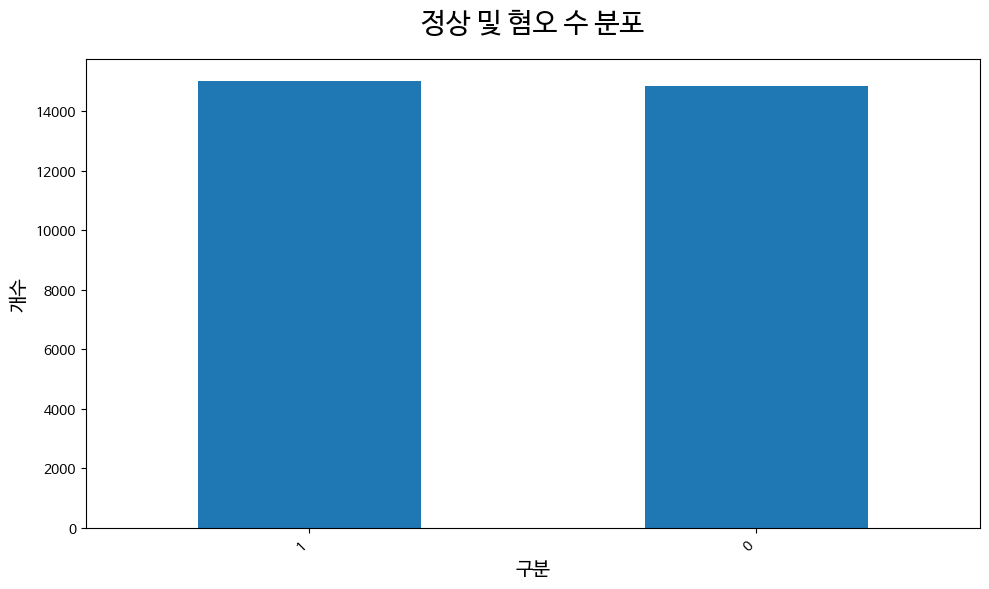

In [45]:
#시각화
plt.figure(figsize=(10, 6))
ax = sum_df.plot(kind='bar')

# x축 라벨 회전
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# 축 제목
ax.set_xlabel('구분', fontsize=14)
ax.set_ylabel('개수', fontsize=14)

# 타이틀 (크기 키우기, 아래 여백 패딩 추가)
ax.set_title('정상 및 혐오 수 분포', fontsize=20, pad=20)

plt.tight_layout()
plt.show()

**[혐오 유형 수]**

In [46]:
sum_df = dataset.loc[:, sub_cols].sum(axis=0)
sum_df

,0
여성/가족,2095
남성,1719
성소수자,1550
인종/국적,2198
연령,811
지역,1705
종교,1544
기타 혐오,752
악플/욕설,4105


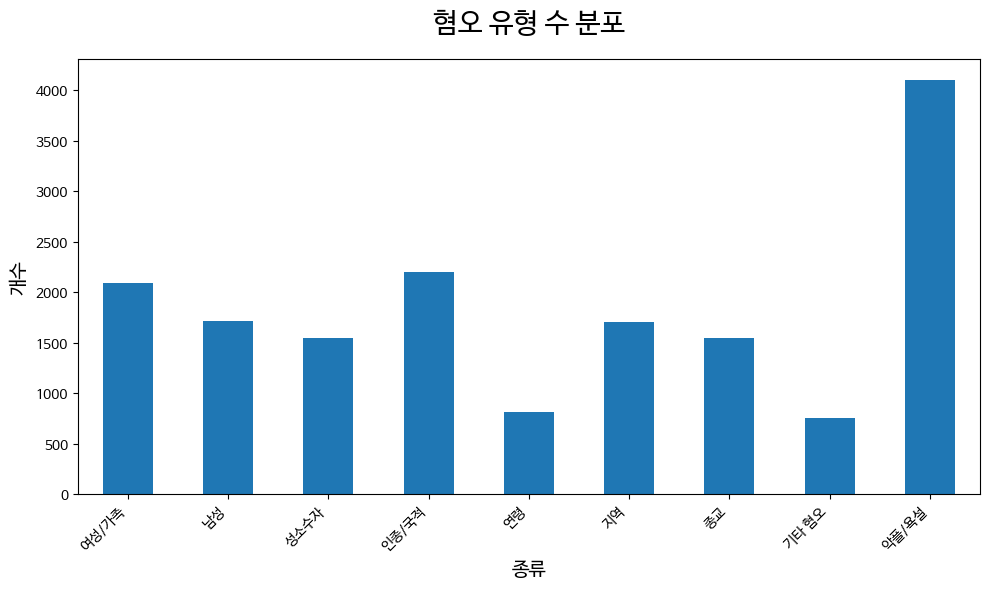

In [47]:
#시각화
plt.figure(figsize=(10, 6))
ax = sum_df.plot(kind='bar')

# x축 라벨 회전
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# 축 제목
ax.set_xlabel('종류', fontsize=14)
ax.set_ylabel('개수', fontsize=14)

# 타이틀 (크기 키우기, 아래 여백 패딩 추가)
ax.set_title('혐오 유형 수 분포', fontsize=20, pad=20)

plt.tight_layout()
plt.show()

**[문장별 혐오 유형 수 분포]**

In [48]:
sum_df = dataset.loc[:, sub_cols].sum(axis=1)
sum_df = sum_df.value_counts()
sum_df

,count
0,14850
1,13652
2,1231
3,102
4,12
6,1
5,1


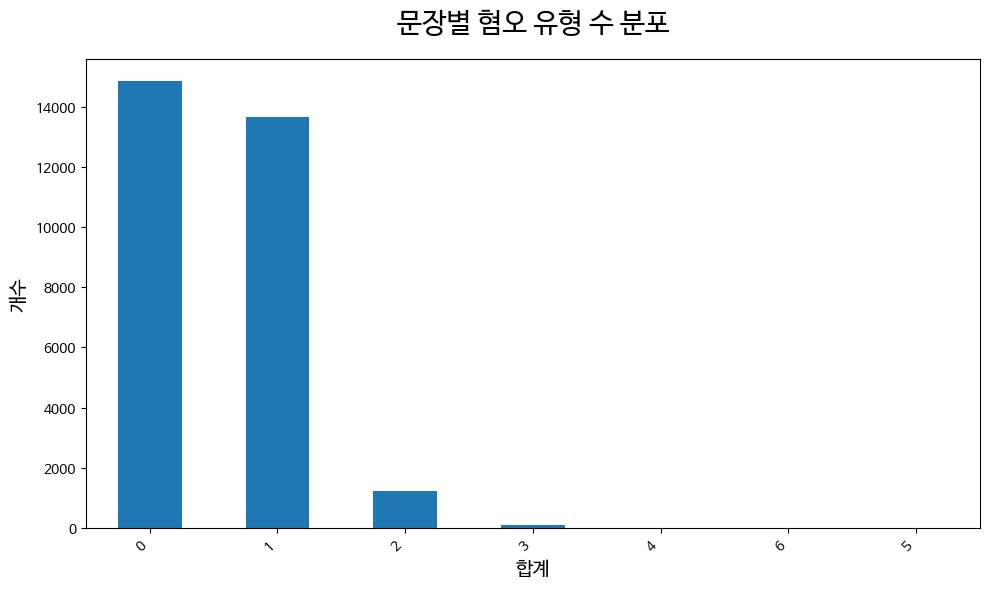

In [49]:
#시각화
plt.figure(figsize=(10, 6))
ax = sum_df.plot(kind='bar')

# x축 라벨 회전
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# 축 제목
ax.set_xlabel('합계', fontsize=14)
ax.set_ylabel('개수', fontsize=14)

# 타이틀 (크기 키우기, 아래 여백 패딩 추가)
ax.set_title('문장별 혐오 유형 수 분포', fontsize=20, pad=20)

plt.tight_layout()
plt.show()

## 3.4 테이블 분리

In [50]:
# 3) 레이블 컬럼(예: 'labels' 또는 'clean') 선택
X = dataset['문장'].values           # 입력 텍스트
y = dataset['target'].values          # 0 or 1 (깨끗한 문장 여부)  ※ 필요에 맞게 바꾸세요

In [51]:
# 4) Train / Val / Test 80 : 10 : 10 분리 ─────────────
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)

In [52]:
X_train

array(['나 웜창인생인데 왜 이거 처음 보노? 앵나 면상 갈렸노', '얘는 난민인 거 같네',
       '아니 새벽두시에 급식충이 피시방에 있다는게 문제가 아니라 밖에 나다니는거 자체가 놀랍다', ...,
       '안녕하세요 리비아에서 온 사람 싫어하지 않았으면 좋겠다고 생각함', '그녀는 이승만 본 적 있나?',
       '조국 수사는 이제 막바지. 기껏해봐야 와이프가 표장장관련 의혹이 전부. 국민을 위한 검찰 개혁이 이렇게 폄하하는 자한당 언제 까지 용납할것인가. 자한당 반드시 청산해야 나라가 한발짝이라도 앞으로 갈것. 이제 적페당에 끌려 다니는 나약한 민주당도 심판하자.'],
      dtype=object)

In [53]:
print(f"Train  : {len(X_train)}")
print(f"Valid. : {len(X_val)}")
print(f"Test   : {len(X_test)}")

Train  : 23879
Valid. : 2985
Test   : 2985


In [54]:
print(f"Train  : 1 : {(y_train == 1).sum()} / 0 : {(y_train == 0).sum()}")
print(f"Valid  : 1 : {(y_val == 1).sum()}  / 0 : {(y_val == 0).sum()}")
print(f"Test   : 1 : {(y_test == 1).sum()}  / 0 : {(y_test == 0).sum()}")

Train  : 1 : 12001 / 0 : 11878
Valid  : 1 : 1500  / 0 : 1485
Test   : 1 : 1500  / 0 : 1485


# <h2>4. 모델 학습</h2>

## 4.1 TF-IDF + Logistic Regression
가장 흔히 사용하는 모델을 선택함

In [55]:
#파이프라인 정의
pipe = make_pipeline(
    TfidfVectorizer(                         # # 토크나이저 정의
        token_pattern=r'(?u)\b[\w가-힣]+\b', # 한글·영문·숫자 단어만 토큰
        ngram_range=(1,2),                   # 1-gram(단어) + 2-gram(연속 두 단어)
        max_features=40000,                  # 가장 빈도 높은 4만개 토큰만
        min_df=2                             # 빈도 2회 미만 토큰 제거 - 노이즈 제거 용도
    ),
    LogisticRegressionCV(                    # # 모델 정의
        cv=5,                                # 5-fold 교차검증
        class_weight='balanced',             # 레이블 빈도에 반비례 가중치
        max_iter=1000,                       # 최대 반복 수
        n_jobs=-1,                           # 병렬 학습
        multi_class='ovr',                   # 이진(vs_rest) 분류 - 기본값임(다중 클래스일 때 대비해 명시)
        solver='lbfgs',                      # 최적화 알고리즘
        random_state=42,                     # 재현성 고정
        scoring='f1'                         # binary F1-score로 C 최적화
    )
)

In [56]:
#학습
pipe.fit(X_train, y_train)
pred = pipe.predict(X_val)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1917: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegressionCV(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [57]:
#모델 저장
joblib.dump(pipe, model_dir+"baseline_tf_logreg.joblib")

['/content/drive/MyDrive/Toxic_Comment_Detection/models/baseline_tf_logreg.joblib']

## 4.2 koBERT

- 사용 모델: monologg/kobert
- https://huggingface.co/monologg/kobert/tree/main

**[토크나이저 로드 & 전처리]**

*NumPy 배열 → Hugging Face Dataset으로 변환

In [58]:
def make_hf_dataset(X, y):
    return Dataset.from_dict({"문장": list(X), "labels": list(y)})

raw_ds = DatasetDict({
    "train":      make_hf_dataset(X_train, y_train),
    "validation": make_hf_dataset(X_val,   y_val),
    "test":       make_hf_dataset(X_test,  y_test),
})

In [59]:
#토크나이저 로드
MODEL_NAME = "monologg/kobert"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

tokenizer_config.json:   0%|          | 0.00/263 [00:00<?, ?B/s]

tokenization_kobert.py:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/monologg/kobert:
- tokenization_kobert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_78b3253a26.model:   0%|          | 0.00/371k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/77.8k [00:00<?, ?B/s]

In [60]:
#TypeError: save_vocabulary() got an unexpected keyword argument 'filename_prefix'” 오류 해결을 위한 패치
#토크나이저 인스턴스가 생성된 직후, 해당 인스턴스의 save_vocabulary 메서드를 래퍼 함수로 덮어써서 filename_prefix 인자를 무시하도록 Monkey-Patch를 적용

#원본 save_vocabulary 백업
_orig_save_vocab = tokenizer.save_vocabulary

#filename_prefix 인자 무시 래퍼 정의
def _patched_save_vocabulary(save_directory, filename_prefix=None):
    return _orig_save_vocab(save_directory)

#인스턴스 메서드 덮어쓰기
tokenizer.save_vocabulary = _patched_save_vocabulary

print("KoBertTokenizer.save_vocabulary 패치 완료")

KoBertTokenizer.save_vocabulary 패치 완료


In [61]:
def preprocess(batch):
    return tokenizer(
        batch["문장"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [62]:
tokenized_ds = raw_ds.map(preprocess, batched=True)
tokenized_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

Map:   0%|          | 0/23879 [00:00<?, ? examples/s]

Map:   0%|          | 0/2985 [00:00<?, ? examples/s]

Map:   0%|          | 0/2985 [00:00<?, ? examples/s]

**[모델 로드 (이진 분류)]**

*base KoBERT 가중치는 로드, 헤드만 랜덤 초기화

In [63]:
#분류 모델 로드 & LoRA 어댑터 적용
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2                                        # 이진 분류(0,1)
    )

lora_cfg = LoraConfig(
    task_type="SEQ_CLS",                                # Sequence Classification(문장 분류) 전용 어댑터 - 분류용 head(CLS 토큰 출력) 위주로 최적화된 구조로 LoRA를 결합하게 됨
    r=8,                                                # LoRA rank - 차원 축소 크기(rank)
    lora_alpha=16,                                      # ΔW에 곱해지는 스케일링 계수
    target_modules=["query", "key", "value"],           # Transformer 어텐션 레이어 중 Q/K/V 프로젝션에만 LoRA를 적용
    inference_mode=False                                # 학습 모드 - LoRA 가중치가 업데이트
)
model = get_peft_model(base_model, lora_cfg)

config.json:   0%|          | 0.00/426 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at monologg/kobert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [64]:
args = TrainingArguments(
    output_dir=output_dir,

    # ─── 평가·저장 주기 설정 ─────────────────────────────
    eval_strategy   = "epoch",   # epoch 단위 평가
    save_strategy   = "epoch",   # epoch 단위 체크포인트 저장
    logging_strategy= "steps",   # 로깅 주기 제어
    logging_steps   = 100,       # 100 스텝마다 로그

    # ─── 학습 설정 ──────────────────────────────────
    num_train_epochs           = 3,
    per_device_train_batch_size= 16,
    per_device_eval_batch_size = 16,
    learning_rate              = 1e-4,
    weight_decay               = 0.01,

    # ─── 최고 모델 저장 설정 ─────────────────────────────
    load_best_model_at_end = True,     # 검증 지표 기반 최적 모델 로드
    metric_for_best_model  = "f1",     # compute_metrics 가 반환하는 키 이름
    greater_is_better      = True,     # 지표 값이 클수록 좋음

    # ─── 기타 ────────────────────────────────────
    fp16=True,      # GPU용 fp16 활성화
    seed = 42,
    report_to="none",       # W&B, tensorboard 등 외부 로깅 전부 끔
)

**[평가 지표 함수 (sklearn 사용)]**

In [65]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall":    recall_score(labels, preds),
        "f1":        f1_score(labels, preds)
    }

**[학습]**

In [66]:
#Trainer 구성
trainer = Trainer(
    model           = model,
    args            = args,
    train_dataset   = tokenized_ds["train"],
    eval_dataset    = tokenized_ds["validation"],
    compute_metrics = compute_metrics,
    tokenizer       = None
)

<ipython-input-66-5643058aa9b3>:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [67]:
trainer.train()   # 약 15분 소요

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.337900,0.344094,0.845226,0.873381,0.809333,0.840138
2,0.301200,0.317143,0.855611,0.886479,0.817333,0.850503
3,0.305600,0.295232,0.869012,0.864563,0.876667,0.870573


TrainOutput(global_step=4479, training_loss=0.3315839978248101, metrics={'train_runtime': 443.7327, 'train_samples_per_second': 161.442, 'train_steps_per_second': 10.094, 'total_flos': 4736544140491776.0, 'train_loss': 0.3315839978248101, 'epoch': 3.0})

In [68]:
#모델 및 토크나이저 저장
trainer.save_model(model_dir)
tokenizer.save_pretrained(model_dir)

('/content/drive/MyDrive/Toxic_Comment_Detection/models/tokenizer_config.json',
 '/content/drive/MyDrive/Toxic_Comment_Detection/models/special_tokens_map.json',
 '/content/drive/MyDrive/Toxic_Comment_Detection/models/tokenizer_78b3253a26.model',
 '/content/drive/MyDrive/Toxic_Comment_Detection/models/vocab.txt',
 '/content/drive/MyDrive/Toxic_Comment_Detection/models/added_tokens.json')

# <h2>5. 모델 평가</h2>

## 5.1 TF-IDF + Logistic Regression

In [69]:
#모델 불러오기
pipe = joblib.load(model_dir+"baseline_tf_logreg.joblib")

In [70]:
#테스트셋 평가
baseline_preds = pipe.predict(X_test)

In [71]:
#성능 확인
print(classification_report(
    y_true=y_test,
    y_pred=baseline_preds,
    digits=4
))

              precision    recall  f1-score   support

           0     0.9464    0.6660    0.7818      1485
           1     0.7443    0.9627    0.8395      1500

    accuracy                         0.8151      2985
   macro avg     0.8454    0.8143    0.8107      2985
weighted avg     0.8449    0.8151    0.8108      2985



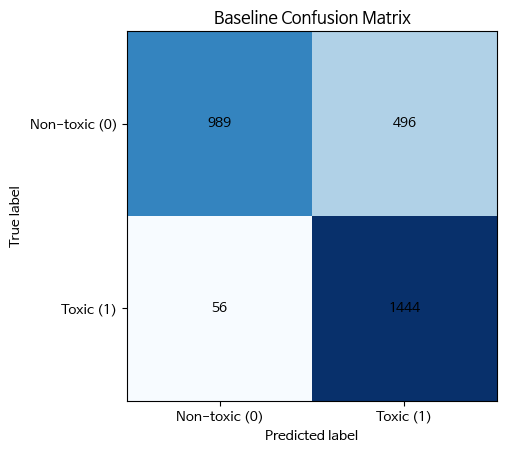

In [72]:
#confusion_matrix
cm_base = confusion_matrix(y_test, baseline_preds)
labels = ['Non-toxic (0)', 'Toxic (1)']

#히트맵
plt.figure()
plt.imshow(cm_base, cmap='Blues')
plt.title('Baseline Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_base[i, j], ha='center', va='center')
plt.show()

## 5.2 KoBERT 기반 모델

In [73]:
#모델 불러오기
model = AutoModelForSequenceClassification.from_pretrained(
    model_dir,
    trust_remote_code=True
)

#토크나이저 불러오기
tokenizer = AutoTokenizer.from_pretrained(model_dir,trust_remote_code=True)

# 패치 코드 실행
_orig = tokenizer.save_vocabulary
def _patched(save_directory, filename_prefix=None):
    return _orig(save_directory)
tokenizer.save_vocabulary = _patched

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at monologg/kobert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [74]:
trainer = Trainer(
  model=model,
  tokenizer=tokenizer
)

#WandbCallback 제거 - 연동 안하려고 제거
trainer.remove_callback(WandbCallback)

<ipython-input-74-4093994d9ea6>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [101]:
#테스트셋 평가
bert_preds = trainer.predict(tokenized_ds["test"])

In [102]:
#성능 확인
bert_preds = np.argmax(bert_preds.predictions, axis=-1)
print(classification_report(y_test, bert_preds, digits=4))

              precision    recall  f1-score   support

           0     0.8611    0.8640    0.8625      1485
           1     0.8649    0.8620    0.8634      1500

    accuracy                         0.8630      2985
   macro avg     0.8630    0.8630    0.8630      2985
weighted avg     0.8630    0.8630    0.8630      2985



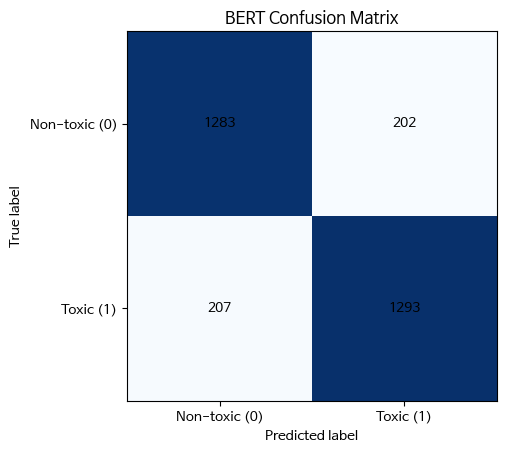

In [80]:
#confusion_matrix
cm_bert = confusion_matrix(y_test, bert_preds)

#히트맵
plt.figure()
plt.imshow(cm_bert, cmap='Blues')
plt.title('BERT Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_bert[i, j], ha='center', va='center')
plt.show()

# <h2>6. 결과 분석</h2>

In [81]:
#결과 df 만들기
df_results = pd.DataFrame({
    "문장": X_test,
    "baseline_pred": baseline_preds,
    "bert_pred": bert_preds
})

#구체적인 분석을 위한 원 테이블과 결합
#'문장'은 unique한 값이므로 key 로 활용 가능 - 해당 데이터에서는
df_results = df_results.merge(dataset, on='문장', how='left')
df_results = df_results[['문장', 'target', 'baseline_pred', 'bert_pred', 'category', '여성/가족', '남성', '성소수자', '인종/국적', '연령', '지역', '종교', '기타 혐오', '악플/욕설']]

In [82]:
#문제 없이 결합된 것 확인
print(len(baseline_preds))
print(len(bert_preds))
df_results.info()

2985
2985
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2985 entries, 0 to 2984
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   문장             2985 non-null   object
 1   target         2985 non-null   int64 
 2   baseline_pred  2985 non-null   int64 
 3   bert_pred      2985 non-null   int64 
 4   category       2985 non-null   object
 5   여성/가족          2985 non-null   int64 
 6   남성             2985 non-null   int64 
 7   성소수자           2985 non-null   int64 
 8   인종/국적          2985 non-null   int64 
 9   연령             2985 non-null   int64 
 10  지역             2985 non-null   int64 
 11  종교             2985 non-null   int64 
 12  기타 혐오          2985 non-null   int64 
 13  악플/욕설          2985 non-null   int64 
dtypes: int64(12), object(2)
memory usage: 326.6+ KB


In [83]:
# Baseline 오분류
base_errors = df_results[df_results["baseline_pred"] != df_results["target"]]
# Baseline 정답
base_correct = df_results[df_results["baseline_pred"] == df_results["target"]]


# BERT 오분류
bert_errors = df_results[df_results["bert_pred"] != df_results["target"]]
# BERT 정답
bert_correct = df_results[df_results["bert_pred"] == df_results["target"]]

## 6.1 어떤 유형의 토픽”에서 오답이 많았는가?

**Base 모델**  
- 오류 유형이 BERT에 비해 비교적 획일적임  
- 모델은 문제성으로 판단했지만, 실제 정답은 정상인 경우 (496건)가 모델은 정상으로 판단했지만, 실제 문제성인 경우 (56건) 에 비해 많았음
- 오답이 많은 토픽 유형: 악플/욕설(21건), 성소수자(8건), 여성/가족(6건), 지역(5건) 순  


In [85]:
base_errors['target'].value_counts()

,count
target,
0,496
1,56


In [86]:
#오류 유형이 base에 비해 비교적 획일적임
base_errors.loc[:,'여성/가족':'악플/욕설'].value_counts().reset_index()

,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,count
0,0,0,0,0,0,0,0,0,0,496
1,0,0,0,0,0,0,0,0,1,21
2,0,0,1,0,0,0,0,0,0,8
3,1,0,0,0,0,0,0,0,0,6
4,0,0,0,0,0,1,0,0,0,5
5,0,0,0,1,0,0,0,0,0,5
6,0,1,0,0,0,0,0,0,0,4
7,0,0,0,0,1,0,0,0,0,4
8,0,0,0,1,0,0,1,0,0,2
9,1,0,1,1,0,0,0,0,0,1


In [87]:
#모델은 문제성으로 봤지만, 정답은 정상으로 본 경우 : 496건
base_errors[base_errors['target'] == 0]

,문장,target,baseline_pred,bert_pred,category,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설
1,공룡이랑 처녀수태도 설명 못하잖아,0,1,1,hatescore,0,0,0,0,0,0,0,0,0
5,비버존잘 뀨,0,1,0,unsmile,0,0,0,0,0,0,0,0,0
14,미.. 이런거 많이들어가는 것도 앵나 여혐. 권력을 쥐어라,0,1,1,unsmile,0,0,0,0,0,0,0,0,0
32,봐라 애들아.,0,1,1,unsmile,0,0,0,0,0,0,0,0,0
34,만약 그녀가 남자를 원하면 혈기왕성한 젊은이가 되어 그녀를 품을 지니... ㅠㅠ,0,1,1,unsmile,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2943,뭐 중3이니까 그나마 그렇긴한데 ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ어후 ㅠㅠ 안타깝다 저 순수할 나이에,0,1,1,unsmile,0,0,0,0,0,0,0,0,0
2948,트렌스젠더는 빨리 죽지 않냐?,0,1,1,hatescore,0,0,0,0,0,0,0,0,0
2958,이건 페미완 상관없는일 같은데 그냥 규정을 악용한 일부 공무원인듯 그 악용한 규정이...,0,1,1,unsmile,0,0,0,0,0,0,0,0,0
2967,구속하라! 대국민 사기꾼,0,1,0,hatescore,0,0,0,0,0,0,0,0,0


In [88]:
#모델은 정상으로 봤지만, '악플/욕설' 유형의 문제가 있는 경우 : 21건
base_errors[base_errors['악플/욕설'] == 1]

,문장,target,baseline_pred,bert_pred,category,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설
191,저출산이 축복이라는게 제일 병신이지저출산=지구에서 도태임,1,0,1,unsmile,0,0,0,0,0,0,0,0,1
331,저거 리어리티쑈 처럼 짜고 치는 고스톱?그래서 내가 우결 저글법칙 진따사나이 러닝맨...,1,0,1,unsmile,0,0,0,0,0,0,0,0,1
441,배신자놈들 다까끼 드럽게빠네 이래서 사람은 배워야해,1,0,1,unsmile,0,0,0,0,0,0,0,0,1
456,이렇게 공분이 클수록 형량은 에게? 3-4년 본다,1,0,0,unsmile,0,0,0,0,0,0,0,0,1
462,902 새끼웜년인데 봊나 고맙노,1,0,1,unsmile,0,0,0,0,0,0,0,0,1
490,그냥다자르고 기계로대체해라.. 저거 지금정규직화해서 나중에 기계화하면 인력들어캐 돌...,1,0,1,unsmile,0,0,0,0,0,0,0,0,1
633,웃기고 있다 그래서 니가 감염되고 가족들 죽어나가도 인권 운운해라,1,0,1,unsmile,0,0,0,0,0,0,0,0,1
686,이낙연 너무 느끼하노,1,0,0,unsmile,0,0,0,0,0,0,0,0,1
741,너무 티나잖아 ㅄㅇ걍 시게노만 했어도 넘어갔을 것을,1,0,1,unsmile,0,0,0,0,0,0,0,0,1
895,총대메고 대한민국의 미래를 위해 니가 희생좀해라 작성자야,1,0,1,unsmile,0,0,0,0,0,0,0,0,1



**BERT 모델**  
- 오류 유형이 Base 모델에 비해 비교적 다양함  
- 모델은 문제성으로 판단했지만 실제 정답은 정상인 경우(221건)가, 모델은 정상으로 판단했지만 실제로는 문제성인 경우(181건)보다 다소 많았음.
- 오답이 많은 토픽 유형: 악플/욕설(99건), 여성/가족(18건), 지역(13건), 성소수자(12건) 순  
- Base 모델과 오답 순서 및 분포는 다르나, 주요 유형은 유사함

In [89]:
bert_errors['target'].value_counts()

,count
target,
1,207
0,202


In [90]:
#오류 유형이 base에 비해 다양함
bert_errors.loc[:,'여성/가족':'악플/욕설'].value_counts().reset_index()

,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,count
0,0,0,0,0,0,0,0,0,0,203
1,0,0,0,0,0,0,0,0,1,111
2,1,0,0,0,0,0,0,0,0,23
3,0,0,0,1,0,0,0,0,0,16
4,0,0,1,0,0,0,0,0,0,15
5,0,0,0,0,0,0,1,0,0,14
6,0,0,0,0,0,1,0,0,0,12
7,0,0,0,0,1,0,0,0,0,5
8,0,1,0,0,0,0,0,0,0,3
9,0,0,0,0,0,0,0,1,0,3


In [91]:
#모델은 문제성으로 봤지만, 정답은 정상으로 본 경우 : 221건
bert_errors[bert_errors['target'] == 0]

,문장,target,baseline_pred,bert_pred,category,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설
1,공룡이랑 처녀수태도 설명 못하잖아,0,1,1,hatescore,0,0,0,0,0,0,0,0,0
14,미.. 이런거 많이들어가는 것도 앵나 여혐. 권력을 쥐어라,0,1,1,unsmile,0,0,0,0,0,0,0,0,0
20,난무신론자지만 성서를읽어봤는데 소설은아니었다 그시대 가장이상적인인간성을 실현한 한분...,0,0,1,unsmile,0,0,0,0,0,0,0,0,0
32,봐라 애들아.,0,1,1,unsmile,0,0,0,0,0,0,0,0,0
34,만약 그녀가 남자를 원하면 혈기왕성한 젊은이가 되어 그녀를 품을 지니... ㅠㅠ,0,1,1,unsmile,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2934,한반도 내에서도 지리적으로 평지가 그나마 많은 전라도 땅이 좋은 땅이고 산지가 많은...,0,1,1,hatescore,0,0,0,0,0,0,0,0,0
2943,뭐 중3이니까 그나마 그렇긴한데 ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ어후 ㅠㅠ 안타깝다 저 순수할 나이에,0,1,1,unsmile,0,0,0,0,0,0,0,0,0
2948,트렌스젠더는 빨리 죽지 않냐?,0,1,1,hatescore,0,0,0,0,0,0,0,0,0
2958,이건 페미완 상관없는일 같은데 그냥 규정을 악용한 일부 공무원인듯 그 악용한 규정이...,0,1,1,unsmile,0,0,0,0,0,0,0,0,0


In [92]:
bert_errors[bert_errors['악플/욕설'] == 1]

,문장,target,baseline_pred,bert_pred,category,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설
16,할 일이 그렇게도 없느냐,1,1,0,unsmile,0,0,0,0,0,0,0,0,1
52,49kg? 매력진짜없다,1,1,0,unsmile,0,0,0,0,0,0,0,0,1
53,환영합니다. 용안이 상당히 어려보이시네요. 츄릅,1,1,0,unsmile,0,0,0,0,0,0,0,0,1
57,화형 부활절실,1,1,0,unsmile,0,0,0,0,0,0,0,0,1
74,우웩 개토나온다 따라가길,1,1,0,unsmile,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2768,노링크 ㅈㅎ,1,1,0,unsmile,0,0,0,0,0,0,0,0,1
2808,북한에 자원이 있긴 있노 이니야 ㅎㅎ,1,1,0,unsmile,0,0,0,0,0,0,0,0,1
2814,자신은 기존 정치인과 다르다고 하더니 지금까지 해왔던 것들이 그대로 답습하고 있군요...,1,1,0,unsmile,0,0,0,0,0,0,0,0,1
2862,강용석이 무슨 생각으로 북한 사람을 대리해서 고위층 탈북자를 고소하냐?? 강용석 요...,1,1,0,unsmile,0,0,0,0,0,0,0,0,1


## 6.2 어떤 유형의 토픽”에서 정답이 많았는가?

**Base 모델**   
- 정상 문장보다 문제성 문장을 더 잘 맞춤
- 악플/욕설(382건), 여성/가족(169건), 인종/국적(166건), 남성(135건), 성소수자(130건) 순으로 정확도가 높았음

In [93]:
base_correct['target'].value_counts()

,count
target,
1,1444
0,989


In [94]:
base_correct.loc[:,'여성/가족':'악플/욕설'].value_counts().reset_index()

,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,count
0,0,0,0,0,0,0,0,0,0,990
1,0,0,0,0,0,0,0,0,1,382
2,1,0,0,0,0,0,0,0,0,169
3,0,0,0,1,0,0,0,0,0,166
4,0,1,0,0,0,0,0,0,0,135
5,0,0,1,0,0,0,0,0,0,130
6,0,0,0,0,0,1,0,0,0,127
7,0,0,0,0,0,0,1,0,0,105
8,0,0,0,0,1,0,0,0,0,62
9,0,0,0,0,0,0,0,1,0,38


In [95]:
base_correct[base_correct['target'] == 0]

,문장,target,baseline_pred,bert_pred,category,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설
0,본관은 추계이며 대구 출생이다.,0,0,0,hatescore,0,0,0,0,0,0,0,0,0
3,저 사람은 강원도에서 온 분이랑 대화했다,0,0,0,hatescore,0,0,0,0,0,0,0,0,0
7,그녀는 동남아에서 태어난 사람인가?,0,0,0,hatescore,0,0,0,0,0,0,0,0,0
11,그는 예멘에서 태어난 사람이랑 싸웠다,0,0,0,hatescore,0,0,0,0,0,0,0,0,0
13,저 사람은 진주에서 온 사람인 거 같네,0,0,0,hatescore,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2970,쟤는 미국 친구인가?,0,0,0,hatescore,0,0,0,0,0,0,0,0,0
2971,보빨남이라는 표현 사용하면 차단입니다,0,0,0,hatescore,0,0,0,0,0,0,0,0,0
2973,저 분은 부산 출신인 사람이랑 대화했다,0,0,0,hatescore,0,0,0,0,0,0,0,0,0
2981,저 분은 아프가니스탄에서 온 사람 싫어하지 않았으면 좋겠다고 생각함,0,0,0,hatescore,0,0,0,0,0,0,0,0,0


In [96]:
base_correct[base_correct['악플/욕설'] == 1]

,문장,target,baseline_pred,bert_pred,category,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설
6,생긴게 원숭이 고릴라 계통이네..우웩 계욕질 나오네 토나올것같아,1,1,1,unsmile,0,0,0,0,0,0,0,0,1
12,와 시발 추수감사절이라고 다진 칠면조로 만들어버리노,1,1,1,unsmile,0,0,0,0,0,0,0,0,1
16,할 일이 그렇게도 없느냐,1,1,0,unsmile,0,0,0,0,0,0,0,0,1
26,그러니까 씹치지ㅉㅉ,1,1,1,unsmile,0,0,0,0,0,0,0,0,1
36,아좆팔 이거쓰러왔는데 늦어부럿노,1,1,1,unsmile,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2937,중국발 바이러스인데 해외유입 차단도 하지않은 정부가 할소리인가? 그리고 외식하라며?,1,1,1,unsmile,0,0,0,0,0,0,0,0,1
2942,이게 나라냐 시발 ㅠ,1,1,1,unsmile,0,0,0,0,0,0,0,0,1
2945,"해외에서 전에 다니던 법인카드가 내 개인 페이팔 계정이 등록되어있어서,이베이서 뭐 ...",1,1,1,unsmile,0,0,0,0,0,0,0,0,1
2961,좋은기사 감사합니다! 그남들 또 몰려와서 파르르 ㅎㅎㅎ 에혀...한심.,1,1,1,unsmile,0,0,0,0,0,0,0,0,1


**BERT 모델**  
- 정상 문장과 문제성 문장을 비슷한 수준으로 잘 맞춤
- 악플/욕설(304건), 인종/국적(158건), 여성/가족(157건), 남성(136건), 성소수자(126건) 순으로 정확도가 높았음

In [97]:
bert_correct['target'].value_counts()

,count
target,
1,1293
0,1283


In [98]:
#오류 유형이 base에 비해 다양함
bert_correct.loc[:,'여성/가족':'악플/욕설'].value_counts().reset_index()

,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,count
0,0,0,0,0,0,0,0,0,0,1283
1,0,0,0,0,0,0,0,0,1,292
2,0,0,0,1,0,0,0,0,0,155
3,1,0,0,0,0,0,0,0,0,152
4,0,1,0,0,0,0,0,0,0,136
5,0,0,1,0,0,0,0,0,0,123
6,0,0,0,0,0,1,0,0,0,120
7,0,0,0,0,0,0,1,0,0,91
8,0,0,0,0,1,0,0,0,0,61
9,0,0,0,0,0,0,0,1,0,35


In [99]:
#모델은 문제성으로 봤지만, 정답은 정상으로 본 경우 : 221건
bert_correct[bert_correct['target'] == 0]

,문장,target,baseline_pred,bert_pred,category,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설
0,본관은 추계이며 대구 출생이다.,0,0,0,hatescore,0,0,0,0,0,0,0,0,0
3,저 사람은 강원도에서 온 분이랑 대화했다,0,0,0,hatescore,0,0,0,0,0,0,0,0,0
5,비버존잘 뀨,0,1,0,unsmile,0,0,0,0,0,0,0,0,0
7,그녀는 동남아에서 태어난 사람인가?,0,0,0,hatescore,0,0,0,0,0,0,0,0,0
11,그는 예멘에서 태어난 사람이랑 싸웠다,0,0,0,hatescore,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2970,쟤는 미국 친구인가?,0,0,0,hatescore,0,0,0,0,0,0,0,0,0
2971,보빨남이라는 표현 사용하면 차단입니다,0,0,0,hatescore,0,0,0,0,0,0,0,0,0
2973,저 분은 부산 출신인 사람이랑 대화했다,0,0,0,hatescore,0,0,0,0,0,0,0,0,0
2981,저 분은 아프가니스탄에서 온 사람 싫어하지 않았으면 좋겠다고 생각함,0,0,0,hatescore,0,0,0,0,0,0,0,0,0


In [100]:
bert_correct[bert_correct['악플/욕설'] == 1]

,문장,target,baseline_pred,bert_pred,category,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설
6,생긴게 원숭이 고릴라 계통이네..우웩 계욕질 나오네 토나올것같아,1,1,1,unsmile,0,0,0,0,0,0,0,0,1
12,와 시발 추수감사절이라고 다진 칠면조로 만들어버리노,1,1,1,unsmile,0,0,0,0,0,0,0,0,1
26,그러니까 씹치지ㅉㅉ,1,1,1,unsmile,0,0,0,0,0,0,0,0,1
36,아좆팔 이거쓰러왔는데 늦어부럿노,1,1,1,unsmile,0,0,0,0,0,0,0,0,1
44,"난 14살때부터 정치 관심 있었는데, 애초에 난 책을 제대로 읽기 시작한 때부터 신...",1,1,1,unsmile,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2937,중국발 바이러스인데 해외유입 차단도 하지않은 정부가 할소리인가? 그리고 외식하라며?,1,1,1,unsmile,0,0,0,0,0,0,0,0,1
2942,이게 나라냐 시발 ㅠ,1,1,1,unsmile,0,0,0,0,0,0,0,0,1
2945,"해외에서 전에 다니던 법인카드가 내 개인 페이팔 계정이 등록되어있어서,이베이서 뭐 ...",1,1,1,unsmile,0,0,0,0,0,0,0,0,1
2961,좋은기사 감사합니다! 그남들 또 몰려와서 파르르 ㅎㅎㅎ 에혀...한심.,1,1,1,unsmile,0,0,0,0,0,0,0,0,1
